# 04 · Como a camada Gold sustenta IA

O desafio pede que o README explique como a base Gold poderia alimentar modelos de
predição de alfabetização. Este notebook não explica: **treina**.

E começa pelo erro que torna inúteis a maioria dos modelos de indicador educacional —
**vazamento de dados (data leakage)**.

In [1]:
import sys
from pathlib import Path

# Caminho relativo: o notebook encontra o projeto a partir da própria posição,
# então funciona em qualquer máquina, sem editar nada.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})
print("Raiz do projeto:", RAIZ.name)

Raiz do projeto: tc2


In [2]:
def ler_gold(tabela: str) -> pd.DataFrame:
    """Lê uma tabela Gold do lakehouse local (Parquet/Delta são compatíveis na leitura)."""
    base = RAIZ / "data" / "lakehouse" / "gold" / tabela
    arquivos = sorted(base.rglob("*.parquet"))
    if not arquivos:
        raise FileNotFoundError(
            f"Tabela gold.{tabela} não encontrada. Rode `make batch` (ou "
            "`python -m src.pipeline --reprocessar`) antes de abrir o notebook."
        )
    partes = []
    for arq in arquivos:
        df = pd.read_parquet(arq)
        # Colunas de partição vêm no caminho (ano=2024), não dentro do arquivo.
        for trecho in arq.relative_to(base).parts[:-1]:
            if "=" in trecho:
                chave, valor = trecho.split("=", 1)
                df[chave] = int(valor) if valor.lstrip("-").isdigit() else valor
        partes.append(df)
    return pd.concat(partes, ignore_index=True)

In [3]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

features = ler_gold("features_ml_municipio")
print(f"{len(features):,} linhas | {features.shape[1]} colunas")
print("Anos disponíveis:", sorted(features["ano"].unique()))
features.head(3)

16,713 linhas | 27 colunas
Anos disponíveis: [np.int32(2023), np.int32(2024), np.int32(2025)]


,ano,id_municipio,nome_municipio,sigla_uf,regiao,alvo_indicador_pct,indicador_ano_anterior_pct,matriculas_ano_anterior,variacao_ano_anterior_pp,meta_pactuada_pct,idhm,idhm_educacao,idhm_renda,renda_per_capita,indice_gini,pct_pobres,pct_criancas_pobres,taxa_analfabetismo_15mais,pct_6a14_fora_escola,pct_criancas_dom_sem_fund,pct_6a14_fund_sem_atraso,pct_agua_encanada,pct_energia_eletrica,populacao_total,porte_municipio,capital,_gold_processed_at
0,2023,1100056,Cerejeiras,RO,Norte,68.0,NaN,NaN,NaN,62.3,0.692,0.602,0.688,577.18,0.5,13.7,22.08,10.29,1.46,35.81,76.2,97.53,98.85,17029.0,PEQUENO,0,2026-08-30 21:26:43.874226
1,2024,1100056,Cerejeiras,RO,Norte,64.9,68.0,235.0,NaN,62.3,0.692,0.602,0.688,577.18,0.5,13.7,22.08,10.29,1.46,35.81,76.2,97.53,98.85,17029.0,PEQUENO,0,2026-08-30 21:26:43.874226
2,2025,1100056,Cerejeiras,RO,Norte,72.2,64.9,235.0,-3.1,65.2,0.692,0.602,0.688,577.18,0.5,13.7,22.08,10.29,1.46,35.81,76.2,97.53,98.85,17029.0,PEQUENO,0,2026-08-30 21:26:43.874226


## 1. O modelo que parece perfeito e não serve para nada

Suponha que alguém treine o modelo com as colunas "óbvias" da tabela municipal:
`alunos_alfabetizados` e `matriculas_avaliadas`.

O indicador **é** `alunos_alfabetizados / matriculas_avaliadas × 100`. O modelo não está
aprendendo nada sobre alfabetização — está redescobrindo uma divisão.

In [4]:
municipal = ler_gold("indicador_alfabetizacao_municipio")
vazado = municipal[municipal["ano"] == 2024].dropna(
    subset=["alunos_alfabetizados", "matriculas_avaliadas", "indicador_pct"])

X_vaz = vazado[["alunos_alfabetizados", "matriculas_avaliadas"]]
y_vaz = vazado["indicador_pct"]
modelo_vazado = GradientBoostingRegressor(random_state=42).fit(X_vaz, y_vaz)
pred_vaz = modelo_vazado.predict(X_vaz)

print(f"R²  com vazamento: {r2_score(y_vaz, pred_vaz):.4f}")
print(f"MAE com vazamento: {mean_absolute_error(y_vaz, pred_vaz):.3f} p.p.")
print("\nR² alto com duas colunas apenas não é sinal de bom modelo:")
print("é sinal de que o alvo está dentro da feature.")

R²  com vazamento: 0.9491
MAE com vazamento: 2.809 p.p.

R² alto com duas colunas apenas não é sinal de bom modelo:
é sinal de que o alvo está dentro da feature.


### Por que isso é fatal em produção

No momento em que a predição seria útil — **antes** da avaliação do ano — nem
`alunos_alfabetizados` nem `matriculas_avaliadas` existem. O modelo teria acurácia
perfeita no papel e nenhuma utilidade no mundo.

Por isso a camada Gold **não deixa** essas colunas entrarem: `src/camadas/gold.py`
mantém a lista `FEATURES_VETADAS` e **falha alto** se alguma delas aparecer na feature
store. A trava é código, não recomendação:

```python
FEATURES_VETADAS = ["alunos_alfabetizados", "matriculas_avaliadas",
                    "indicador_uf_pct", "gap_meta_pp"]

vazadas = [c for c in FEATURES_VETADAS if c in df.columns]
if vazadas:
    raise RuntimeError(f"Vazamento detectado na feature store: {vazadas}.")
```

## 2. O modelo honesto

`gold.features_ml_municipio` só contém o que se conhece **antes** do ano do alvo:
contexto socioeconômico do Censo, indicador defasado (t−1) e a meta pactuada.

Validação **temporal**, não aleatória: treina em 2024, testa em 2025. Embaralhar anos
seria outra forma de vazamento — o modelo veria o futuro do próprio município.

In [5]:
COLUNAS_X = [
    "indicador_ano_anterior_pct", "meta_pactuada_pct", "idhm", "idhm_educacao",
    "idhm_renda", "renda_per_capita", "indice_gini", "pct_pobres", "pct_criancas_pobres",
    "taxa_analfabetismo_15mais", "pct_6a14_fora_escola", "pct_criancas_dom_sem_fund",
    "pct_6a14_fund_sem_atraso", "pct_agua_encanada", "pct_energia_eletrica",
    "populacao_total", "capital",
]

base = features.dropna(subset=["alvo_indicador_pct", "indicador_ano_anterior_pct"] + COLUNAS_X)
treino = base[base["ano"] == 2024]
teste = base[base["ano"] == 2025]
print(f"Treino (2024): {len(treino):,} municípios | Teste (2025): {len(teste):,} municípios")

X_tr, y_tr = treino[COLUNAS_X], treino["alvo_indicador_pct"]
X_te, y_te = teste[COLUNAS_X], teste["alvo_indicador_pct"]

resultados = []
for nome, modelo in [
    ("Ridge", Ridge(alpha=1.0)),
    ("Gradient Boosting", GradientBoostingRegressor(random_state=42, n_estimators=300,
                                                    max_depth=3, learning_rate=0.05)),
]:
    modelo.fit(X_tr, y_tr)
    pred = modelo.predict(X_te)
    resultados.append({"modelo": nome,
                       "R2_teste": round(r2_score(y_te, pred), 3),
                       "MAE_teste_pp": round(mean_absolute_error(y_te, pred), 2)})

# Baseline honesto: repetir o valor do ano anterior.
baseline = teste["indicador_ano_anterior_pct"]
resultados.append({"modelo": "Baseline (repete t-1)",
                   "R2_teste": round(r2_score(y_te, baseline), 3),
                   "MAE_teste_pp": round(mean_absolute_error(y_te, baseline), 2)})

pd.DataFrame(resultados)

Treino (2024): 5,564 municípios | Teste (2025): 5,564 municípios


,modelo,R2_teste,MAE_teste_pp
0,Ridge,0.743,7.25
1,Gradient Boosting,0.753,7.01
2,Baseline (repete t-1),0.670,8.31


Compare com a seção anterior: o modelo vazado alcançou **R² 0,95 com erro de 2,8 p.p.**,
usando duas colunas que **não existem** no momento em que a predição seria feita. O modelo
honesto fica em torno de **R² 0,75 com erro de 7 p.p.** — e esse é o número que descreve o
que a solução realmente consegue prever.

Note também o baseline: qualquer modelo que não supere "repetir o valor do ano anterior"
não merece ir para produção. O ganho aqui é real, mas medido — não inflado.

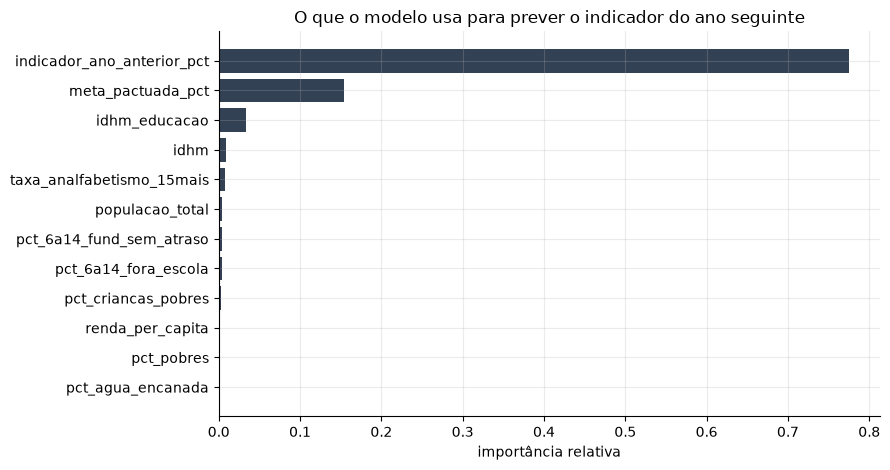

In [6]:
melhor = GradientBoostingRegressor(random_state=42, n_estimators=300,
                                   max_depth=3, learning_rate=0.05).fit(X_tr, y_tr)
importancia = (pd.Series(melhor.feature_importances_, index=COLUNAS_X)
                 .sort_values(ascending=True).tail(12))

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(importancia.index, importancia.values, color="#334155")
ax.set_title("O que o modelo usa para prever o indicador do ano seguinte")
ax.set_xlabel("importância relativa")
plt.tight_layout(); plt.show()

## 3. Três usos da base Gold que o desafio pede

### a) Predição de alfabetização por município
O modelo acima aponta, **antes da avaliação**, quais municípios tendem a ficar abaixo da
meta. Isso transforma a política de reativa em preventiva: o apoio técnico chega no
começo do ano letivo, não no relatório do ano seguinte.

### b) Análise de desigualdade educacional
`gold.painel_desigualdade` cruza indicador, região e quartil de IDHM. O notebook 03 mostra
mais de 30 pontos percentuais de diferença entre o quartil mais alto e o mais baixo —
evidência direta para desenhar política focalizada.

### c) Política pública baseada em dados
Com `indicador_alfabetizacao_municipio` é possível agrupar municípios por perfil de
vulnerabilidade e simular cenários: quantas crianças a mais seriam alfabetizadas se os
municípios do quartil inferior avançassem ao ritmo médio dos demais.

In [7]:
m24 = municipal[municipal["ano"] == 2024].dropna(subset=["idhm"])
q1 = m24[m24["idhm"] <= m24["idhm"].quantile(0.25)]
ritmo_demais = 3.3  # variação nacional observada entre 2023 e 2024, em p.p.

ganho = (q1["matriculas_avaliadas"] * ritmo_demais / 100).sum()
print(f"Municípios no quartil de menor IDHM: {len(q1):,}")
print(f"Crianças não alfabetizadas hoje nesses municípios: "
      f"{q1['alunos_nao_alfabetizados'].sum():,.0f}")
print(f"Se avançassem {ritmo_demais} p.p. em um ano (ritmo nacional de 2023→2024), "
      f"seriam ~{ganho:,.0f} crianças alfabetizadas a mais.")

Municípios no quartil de menor IDHM: 1,399
Crianças não alfabetizadas hoje nesses municípios: 259,088
Se avançassem 3.3 p.p. em um ano (ritmo nacional de 2023→2024), seriam ~13,072 crianças alfabetizadas a mais.


## 4. O que a arquitetura garante para o modelo

| Requisito de IA | O que a pipeline entrega |
|---|---|
| Feature store estável | Grão declarado em contrato: uma linha por município e ano |
| Ausência de vazamento | Lista de colunas vetadas com trava que falha a execução |
| Reprodutibilidade | Time travel do Delta: treinar de novo com o dado exato de uma data |
| Qualidade da entrada | Contratos aplicados antes de a feature existir |
| Rastreabilidade | `_run_id` e `origem_indicador` acompanham cada linha até a Gold |